What is the price distribution of menu items?

In [83]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster # библиотека для создания интерактивных карт
conn = sqlite3.connect('data/takeaway.db')

## Query 1: price distribution of menu items

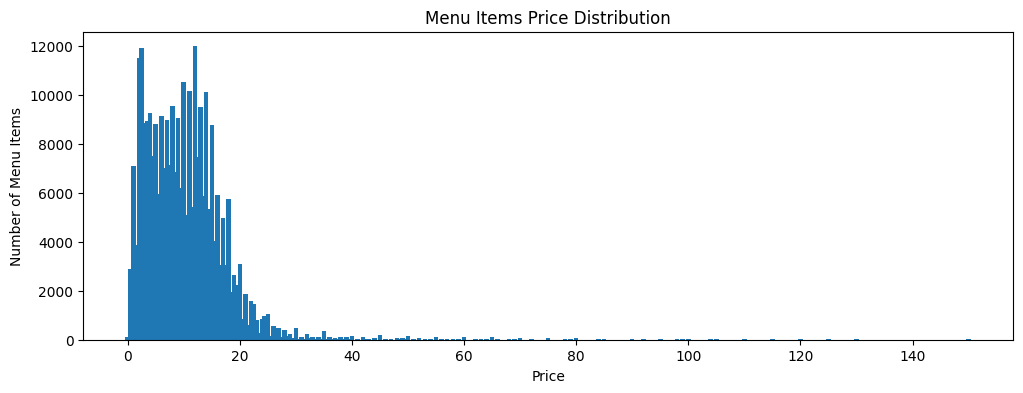

In [84]:
query = """
    SELECT price, COUNT(*) AS count
    FROM menuItems
    GROUP BY price
    ORDER BY price DESC;
    """
df = pd.read_sql_query(query, conn)

plt.figure(figsize=(12,4))
plt.bar(df['price'], df['count'])
plt.xlabel('Price')
plt.ylabel('Number of Menu Items')
plt.title('Menu Items Price Distribution')
plt.show()

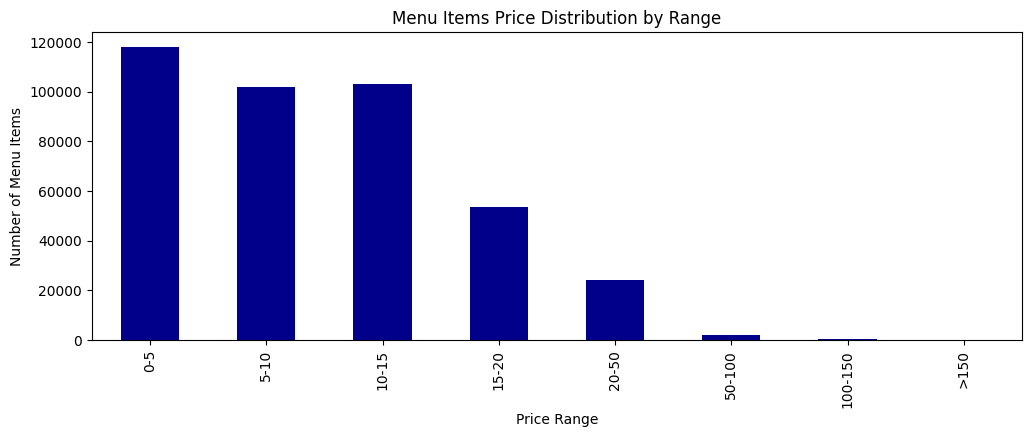

In [85]:
df = pd.read_sql_query("SELECT price FROM menuItems;", conn)

# биннинг (англ. bin — корзина)- процесс превращения непрерывных чисел в понятные категории (диапазоны)
bins = [0, 5, 10, 15, 20, 50, 100, 150, df['price'].max()+1] # границы диапазонов, задаю вручную: от 0 до 5, от 5 до 10 и т.д.
labels = ['0-5', '5-10', '10-15', '15-20', '20-50', '50-100', '100-150', '>150'] # текстовые названия для этих корзин

# pd.cut() - функция берет каждую цену из столбца price и смотрит, в какой интервал из bins она попадает.
# right=False: левая граница включается, правая — нет
df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels, right=False)

price_distribution = df['price_range'].value_counts().sort_index() # подсчет блюд в каждом диапазоне

plt.figure(figsize=(12,4))
price_distribution.plot(kind='bar', color='darkblue')
plt.xlabel('Price Range')
plt.ylabel('Number of Menu Items')
plt.title('Menu Items Price Distribution by Range')
plt.savefig('graphs/plot_q1.png', bbox_inches='tight', dpi=300)
plt.show()

## Query 2: distribution of restaurants per location

In [86]:
query = """
SELECT city, COUNT(*) AS restaurant_count
FROM restaurants
GROUP BY city
ORDER BY restaurant_count DESC;
"""

df_city_count = pd.read_sql_query(query, conn)

df_city_count.head(10)

,city,restaurant_count
0,Antwerpen,437
1,Gent,309
2,Bruxelles,264
3,Leuven,174
4,Schaerbeek,111
5,Brugge,96
6,Oostende,85
7,Mechelen,84
8,Anderlecht,84
9,Deurne,56


In [87]:
query = """
SELECT primarySlug, name, city, latitude, longitude, ratings, durationRangeMin, durationRangeMax, deliveryFee
FROM restaurants
WHERE latitude IS NOT NULL AND longitude IS NOT NULL;
"""
df_restaurants = pd.read_sql_query(query, conn)
df_restaurants.head()

,primarySlug,name,city,latitude,longitude,ratings,durationRangeMin,durationRangeMax,deliveryFee
0,pasta-pino,Pasta Pino,Mouscron,50.743630,3.216888,4.6,15,40,3.0
1,da-barone-et-fils,Da Barone et Fils,Neupré,50.540992,5.460752,3.0,80,100,3.0
2,pizza-gustosa,Pizza Gustosa,Awans,50.675491,5.480206,4.6,20,45,4.0
3,la-brezza-nova-rocourt-1,La Brezza Nova Rocourt,Liège,50.684180,5.549703,4.3,40,65,5.0
4,la-storia-ans,La Storia,Liège,50.663340,5.512421,4.2,45,70,5.0


In [88]:
m = folium.Map(location=[50.8467, 4.3524], zoom_start=9)

marker_cluster = MarkerCluster().add_to(m)

for idx, row in df_restaurants.iterrows():
    popup_text = f"""
    <b>{row['name']}</b><br>
    City: {row['city']}<br>
    Rating: {row['ratings']}<br>
    Delivery: {row['durationRangeMin']}-{row['durationRangeMax']} min<br>
    Fee: {row['deliveryFee']} €
    """
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=popup_text
    ).add_to(marker_cluster)

m.save('maps/delivery_map.html')

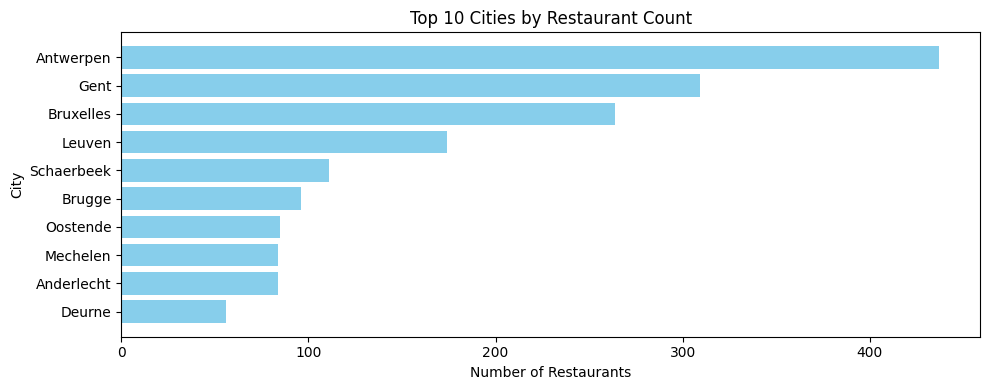

In [89]:
query = """
SELECT city, COUNT(*) AS restaurant_count
FROM restaurants
GROUP BY city
ORDER BY restaurant_count DESC
LIMIT 10;
"""

df_top10 = pd.read_sql_query(query, conn)
df_top10.head(10)

plt.figure(figsize=(10,4))
plt.barh(df_top10['city'], df_top10['restaurant_count'], color='skyblue')
plt.xlabel('Number of Restaurants')
plt.ylabel('City')
plt.title('Top 10 Cities by Restaurant Count')
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.savefig('graphs/plot_q2.png', bbox_inches='tight', dpi=300)
plt.show()

## Query 3: top 10 pizza restaurants by rating

In [90]:
"""
Внутрениий запрос:
JOIN menuItems m ON r.primarySlug = m.primarySlug: соединяем таблицу ресторанов с их меню (меню по всем заведениям).
WHERE m.name LIKE '%Pizz%': оставляем только рестораны, у которых в меню есть хотя бы одно блюдо со словом "Pizz".
MAX(m.name) AS category: хитрость = поскольку мы группируем данные, нам нужно выбрать какое-то одно название блюда для отображения (чтобы подтвердить, что пицца там есть).
GROUP BY ...: объединяем все строки по ресторанам, чтобы один ресторан не повторялся 10 раз из-за 10 видов пиццы в меню.
ORDER BY r.ratingsNumber DESC LIMIT 100: Мы выбираем Топ-50 самых популярных мест (где оставили больше всего отзывов)
Внешний запрос (среди топ=100 по отзывам):
WHERE ratings >= 4.5: отсеиваем только те, у которых «звездность» >= 4.5
ORDER BY ratings DESC: Сортируем по убыванию рейтинга
"""

query = """
SELECT *
FROM (
    SELECT r.primarySlug,
           r.name,
           MAX(m.name) AS category,
           r.city,
           r.ratings,
           r.ratingsNumber,
           r.deliveryFee,
           r.durationRangeMin,
           r.durationRangeMax
    FROM restaurants r
    JOIN menuItems m
      ON r.primarySlug = m.primarySlug
    WHERE m.name LIKE '%Pizz%'
    GROUP BY r.primarySlug, r.name, r.city, r.ratings, r.ratingsNumber, r.deliveryFee, r.durationRangeMin, r.durationRangeMax
    ORDER BY r.ratingsNumber DESC
    LIMIT 100
) AS top_votes
WHERE ratings >= 4.5
ORDER BY ratings DESC
LIMIT 10;
"""
top_10_pizza = pd.read_sql_query(query, conn)
top_10_pizza

,primarySlug,name,category,city,ratings,ratingsNumber,deliveryFee,durationRangeMin,durationRangeMax
0,pizza-minute-schaerbeek,Pizza Minute,Pizza petite,Schaerbeek,4.9,2833,0.00,30,55
1,pizza-heat-wetteren,Pizza Heat,Pizza small,Wetteren,4.9,1786,0.00,25,50
2,pizza-pasta-concept,Pizza Pasta Concept,Basis pizza small,Deurne,4.8,2894,1.00,15,40
3,pizza-viaaa,Pizza Viaaa,Pizza dinde fumée,Machelen,4.8,2114,2.99,20,45
4,pizza-alba,Il Girasole,Pizza vivaldi,Bruxelles,4.8,1869,0.00,20,45
5,pizza-di-trevi-1,Pizza Di Trevi,Pizza veggie spicy,Brugge,4.7,4902,2.00,20,45
6,cesars,Cesars,Pizza vis (M),Putte,4.7,3632,0.00,15,40
7,sipan,Pizzeria Sipan,Pizza vegetarisch,Betekom,4.7,1627,3.00,30,55
8,pizza-vera,Pizza Vera,Pizza casa,Vilvorde,4.6,3349,0.00,30,55
9,pinocchio-2170,Pinocchio,Pizza vegetariana,Merksem,4.6,2109,0.00,25,50


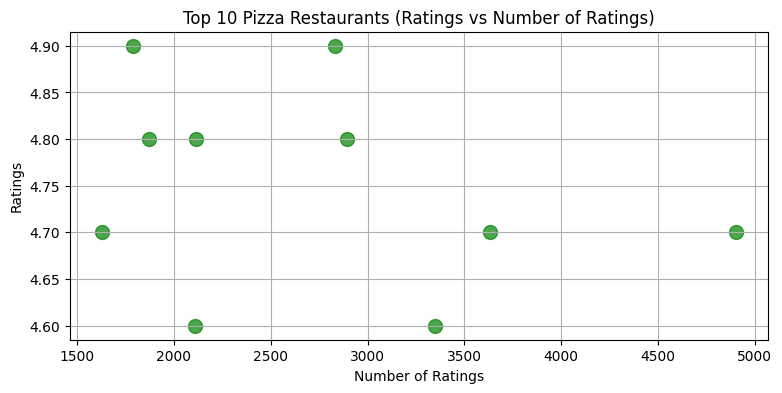

In [91]:
plt.figure(figsize=(9,4))
plt.scatter(
    top_10_pizza['ratingsNumber'],  
    top_10_pizza['ratings'],        
    s=100,                          
    c='green',                     
    alpha=0.7
)

plt.xlabel('Number of Ratings')
plt.ylabel('Ratings')
plt.title('Top 10 Pizza Restaurants (Ratings vs Number of Ratings)')
plt.grid(True)
plt.show()

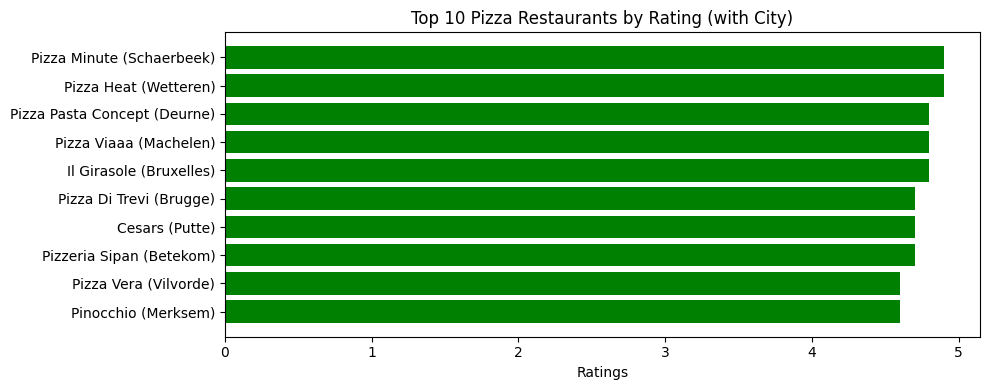

In [92]:
top_10_pizza['label'] = top_10_pizza['name'] + " (" + top_10_pizza['city'] + ")"

plt.figure(figsize=(10,4))
plt.barh(
    top_10_pizza['label'],
    top_10_pizza['ratings'],
    color='green'
)

plt.xlabel('Ratings')
plt.title('Top 10 Pizza Restaurants by Rating (with City)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('graphs/plot_q3.png', bbox_inches='tight', dpi=300)
plt.show()

## Query 4: Map locations offering pasta and their average price

In [93]:
query = """
SELECT r.primarySlug,
       r.name,
       r.city, 
       r.latitude, 
       r.longitude,
       AVG(m.price) as avg_price, 
       GROUP_CONCAT(m.name, ', ') AS pasta_items
FROM restaurants r
JOIN menuItems m
    ON r.primarySlug = m.primarySlug
WHERE m.name LIKE '%past%'
GROUP BY r.primarySlug, r.name, r.city, r.latitude, r.longitude
"""
df_restaurants = pd.read_sql_query(query, conn)
df_restaurants.head()

,primarySlug,name,city,latitude,longitude,avg_price,pasta_items
0,2taste-antwerpen,2Taste,Antwerpen,51.214090,4.444752,13.5,"Pasta bolognese, Pasta al forno, Pasta pollo, ..."
1,4-seizoene,4 Seizoenen,Brasschaat,51.293016,4.494523,14.0,Pasta mista
2,a-modo-mio-saint-gilles,A Modo Mio,Bruxelles,50.836631,4.339464,14.0,Antipasto rustico
3,aba-jour,Aba-Jour,Gent,51.058029,3.724200,11.0,"Pasta pesto, Pasta"
4,abu-simbel-1,Eethuis Turnhout,Turnhout,51.319332,4.949775,11.5,"Pasta Napolitana, Pasta bolognese, Pasta kaas ..."


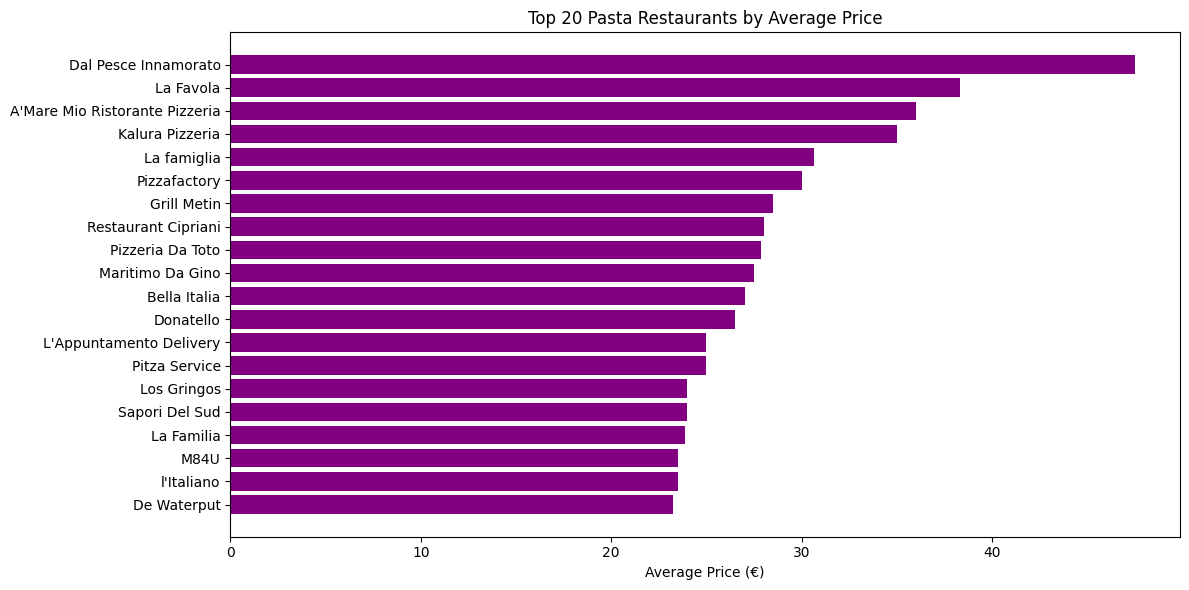

In [94]:
plt.figure(figsize=(12,6))
top20_pasta = df_restaurants.sort_values("avg_price", ascending=False).head(20)

plt.barh(top20_pasta['name'], top20_pasta['avg_price'], color='purple')
plt.xlabel('Average Price (€)')
plt.title('Top 20 Pasta Restaurants by Average Price')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.savefig('graphs/plot_q4.png', bbox_inches='tight', dpi=300)
plt.show()

In [95]:
m = folium.Map(location=[50.85, 4.35], zoom_start=9)

marker_cluster = MarkerCluster().add_to(m)

for idx, row in df_restaurants.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"{row['name']}<br>Avg Price: €{row['avg_price']:.2f}"
    ).add_to(marker_cluster)

m.save("maps/pasta_map.html")

## Query 5: Which restaurants have the best price-to-rating ratio?

In [96]:
query = """ 
    SELECT r.primarySlug,
           r.name,
           r.city,
           r.ratings,
           r.ratingsNumber,
           r.deliveryFee,
           r.durationRangeMin,
           r.durationRangeMax,
           r.ratings/ m_avg.avg_price AS price_to_rating_ratio
    FROM restaurants r
    JOIN (
        SELECT primarySlug,
               AVG(price) AS avg_price
        FROM menuItems
        GROUP BY primarySlug) m_avg
    ON r.primarySlug = m_avg.primarySlug
    WHERE m_avg.avg_price > 0
    ORDER BY price_to_rating_ratio DESC
    LIMIT 10;

"""
top_10 = pd.read_sql_query(query, conn)
top_10

,primarySlug,name,city,ratings,ratingsNumber,deliveryFee,durationRangeMin,durationRangeMax,price_to_rating_ratio
0,le-corner-1,Le Corner,Jette,5.0,3,0.00,20,45,2.115656
1,el-bocadillos,El Bocadillos,Bruxelles,4.2,307,5.59,55,65,2.100000
2,boulangerie-salam,Boulangerie Salam,Molenbeek-Saint-Jean,4.1,21,5.59,45,55,2.010262
3,doce-tentacao-patisserie,Pâtisserie Doce Tentação,Saint-Gilles,5.0,6,5.59,60,70,1.904762
4,bazi-boulangerie,Bazi Boulangerie,Anderlecht,4.3,10,5.59,45,55,1.841310
5,amigos,Frituur Amigos,Wilrijk,4.3,1172,0.00,25,50,1.782927
6,frituur-t-krokantje,Frituur 't Krokantje,Sint-Gillis-Waas,4.9,19,2.00,15,40,1.764000
7,quetacos,QueTacos,Maasmechelen,5.0,157,2.50,20,45,1.750000
8,frituur-opt-hoekske,Frituur op't Hoekske,Vilvoorde,5.0,14,3.00,20,45,1.747641
9,frituur-4-you,Frituur 4 You,Vilvorde,4.7,220,0.00,20,45,1.746906


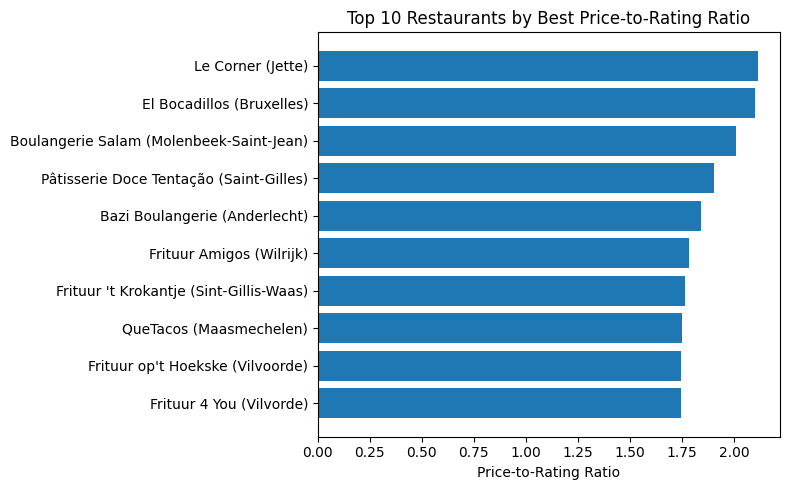

In [97]:
top_10['label'] = top_10['name'] + " (" + top_10['city'] + ")"

plt.figure(figsize=(8, 5))

plt.barh(
    top_10['label'],
    top_10['price_to_rating_ratio']
)

plt.xlabel('Price-to-Rating Ratio')
plt.title('Top 10 Restaurants by Best Price-to-Rating Ratio')
plt.gca().invert_yaxis()  # 
plt.tight_layout()
plt.savefig('graphs/plot_q5.png', bbox_inches='tight', dpi=300)
plt.show()

In [98]:
query_cte_fixed = """

WITH avg_price_cte AS (
    SELECT primarySlug,
           AVG(price) AS avg_price
    FROM menuItems
    GROUP BY primarySlug
)
SELECT r.primarySlug,
       r.name,
       r.city,
       r.ratings,
       r.ratingsNumber,
       r.deliveryFee,
       r.durationRangeMin,
       r.durationRangeMax,
       r.ratings / avg_price_cte.avg_price AS price_to_rating
FROM restaurants r
JOIN avg_price_cte
  ON r.primarySlug = avg_price_cte.primarySlug
WHERE avg_price_cte.avg_price > 0
ORDER BY price_to_rating DESC
LIMIT 10;


"""
top_10 = pd.read_sql_query(query, conn)
top_10

,primarySlug,name,city,ratings,ratingsNumber,deliveryFee,durationRangeMin,durationRangeMax,price_to_rating_ratio
0,le-corner-1,Le Corner,Jette,5.0,3,0.00,20,45,2.115656
1,el-bocadillos,El Bocadillos,Bruxelles,4.2,307,5.59,55,65,2.100000
2,boulangerie-salam,Boulangerie Salam,Molenbeek-Saint-Jean,4.1,21,5.59,45,55,2.010262
3,doce-tentacao-patisserie,Pâtisserie Doce Tentação,Saint-Gilles,5.0,6,5.59,60,70,1.904762
4,bazi-boulangerie,Bazi Boulangerie,Anderlecht,4.3,10,5.59,45,55,1.841310
5,amigos,Frituur Amigos,Wilrijk,4.3,1172,0.00,25,50,1.782927
6,frituur-t-krokantje,Frituur 't Krokantje,Sint-Gillis-Waas,4.9,19,2.00,15,40,1.764000
7,quetacos,QueTacos,Maasmechelen,5.0,157,2.50,20,45,1.750000
8,frituur-opt-hoekske,Frituur op't Hoekske,Vilvoorde,5.0,14,3.00,20,45,1.747641
9,frituur-4-you,Frituur 4 You,Vilvorde,4.7,220,0.00,20,45,1.746906
